# IMPORTANTE 
##### BASE DE DADOS INCOMPATÍVEL COM ESTATÍSTICAS NUMÉRICAS, HISTOGRAMAS, BOXPLOTS, OUTLIERS, SÉRIES TEMPORAIS, SEGMENTAÇÃO POR MÉTRICAS NUMÉRICAS E ANÁLISE MULTIVARIADA NUMÉRICA

A base de dados escolhida possui apenas dados de exercícios físicos, grupos musculares, instruções para realização e máquinas a serem utilizadas. O objetivo dessa extração de dados no projeto é alimentar um banco de dados informativo de exercícios e ser usado como base de conhecimento para um LLM da aplicação.

Por esse motivo, algumas análises do notebook não são aplicáveis a essa base. Mesmo assim, a execução é importante para identificar as características, os valores ausentes e as limitações dos dados disponíveis.


### FLUXO LLM

LLM recebe dados para prototipação de treinos personalizados para alunos com base em:

- Informações dos últimos 5 agendamentos com personal (histórico de treino)
- Objetivo do aluno preenchido em anamnese
- Objetivo de treino definido pelo próprio personal
- **NOVO** - LLM consulta banco de dados com treinos de diversos tipos para realização de treinamento físico para o profissional recomendar aos alunos.

### IMPACTO EM APLICAÇÃO

Ao adicionar uma fonte de dados confiáveis de treinos físicos, diminuímos a possibilidade de alucinação do LLM, mitigando a chance de recomendar treinos inexistentes ou treinos com grupos musculares não condizentes com o treino realizado. Ainda assim, a base precisa ser validada por um profissional da área, e as recomendações geradas pelo LLM devem ser avaliadas por um profissional de educação física.


### EXECUÇÃO - fluxo TextToSql

1. LLM recebe informação.
2. Realiza query em banco de dados filtrando os exercícios mais condizentes para aquele objetivo.
3. Outra chamada para LLM realiza inferência de informações e realiza prototipação de treino.
4. O profissional avalia e valida a recomendação antes de apresentá-la ao aluno.

---

<h1>SPTech — Análise de Dados</h1>
<h1>EDA — Análise Exploratória de Dados</h1>

Este notebook executa um roteiro completo de EDA sobre **qualquer base tabular**.

Para usar na base do seu Projeto de Inovação, altere **apenas a célula de configuração** logo abaixo e execute tudo (`Executar tudo` / `Run all`). Nenhuma outra célula precisa ser editada.

O roteiro segue a ordem apresentada na Aula 6:

| Seção | Conteúdo |
| --- | --- |
| 0 | Configuração e carga |
| 1 | Estrutura, grão e chave |
| 2 | Qualidade: nulos, nulos disfarçados, duplicatas |
| 3 | Univariada numérica: centro, dispersão, forma, extremos |
| 4 | Univariada categórica: frequência, cardinalidade, cauda longa |
| 5 | Outliers: IQR, z-score e z-score modificado |
| 6 | Séries temporais: tendência, sazonalidade, quebras |
| 7 | Bivariada: o gráfico certo para cada par de tipos |
| 8 | Correlação: Pearson, Spearman e o alerta de Anscombe |
| 9 | Segmentação com o n ao lado |
| 10 | Multivariada: facetas, confundimento e teste de Simpson |
| 11 | Síntese: achados, hipóteses e decisões |

---

# 0) Configuração

**Esta é a única célula que você precisa alterar.**

Preencha o caminho do arquivo e, se quiser, indique as colunas que têm papel especial. Tudo o que ficar vazio é detectado automaticamente.

In [1]:
# ═══════════════════════════════════════════════════════════════════
#  CONFIGURAÇÃO — altere apenas esta célula
# ═══════════════════════════════════════════════════════════════════

CAMINHO  = "exercises(2).csv"   # caminho do seu arquivo
SEP      = ","            # separador de campos: "," ou ";" ou "\t"
ENCODING = "utf-8-sig"       # "utf-8", "utf-8-sig" ou "latin1"
DECIMAL  = "."            # "." ou "," conforme o arquivo

# Opcionais — deixe como está para detecção automática
COLS_DATA    = []         # ex: ["dt_agendamento", "dt_consulta"]
COL_ALVO     = None       # variável de interesse, ex: "situacao"
COLS_IGNORAR = ['id', 'gifUrl']         # identificadores a excluir das análises numéricas
GRAO         = ['id']         # colunas que identificam uma linha, ex: ["id_pedido"]

# Valores que devem ser lidos como ausentes
NA_EXTRA = ["", "-", "--", "N/A", "NA", "n/a", "não informado",
            "nao informado", "sem dado", "null", "NULL", "?", "#N/D"]

# Ajustes de exibição
MAX_CATEGORIAS  = 15      # categorias mostradas nos gráficos de barras
MIN_N_SEGMENTO  = 30      # n mínimo para um segmento ser considerado confiável
# ═══════════════════════════════════════════════════════════════════

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.titlesize"] = 12

print("Bibliotecas carregadas. Pandas", pd.__version__)

Bibliotecas carregadas. Pandas 3.0.6


## 0.1) Carga

A leitura é feita **com tudo como texto**, como vimos na Aula 5: a conversão de tipos é decisão nossa, não palpite da biblioteca. A conversão acontece na célula seguinte, e o que não converter fica registrado.

In [3]:
df_bruto = pd.read_csv(
    CAMINHO,
    sep=SEP,
    encoding=ENCODING,
    dtype=str,
    na_values=NA_EXTRA,
    keep_default_na=True,
)

print(f"Arquivo: {CAMINHO}")
print(f"Linhas: {df_bruto.shape[0]:,}   Colunas: {df_bruto.shape[1]}".replace(",", "."))
df_bruto.head()

Arquivo: exercises(2).csv
Linhas: 1.324   Colunas: 23


,bodyPart,equipment,gifUrl,id,name,target,secondaryMuscles/0,secondaryMuscles/1,instructions/0,instructions/1,instructions/2,instructions/3,instructions/4,instructions/5,secondaryMuscles/2,instructions/6,instructions/7,secondaryMuscles/3,instructions/8,secondaryMuscles/4,instructions/9,secondaryMuscles/5,instructions/10
0,waist,body weight,https://v2.exercisedb.io/image/MOnK4iG0MEt9h8,0001,3/4 sit-up,abs,hip flexors,lower back,Lie flat on your back with your knees bent and...,Place your hands behind your head with your el...,"Engaging your abs, slowly lift your upper body...","Pause for a moment at the top, then slowly low...",Repeat for the desired number of repetitions.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,waist,body weight,https://v2.exercisedb.io/image/PERWLDGUxVbpHS,0002,45° side bend,abs,obliques,NaN,Stand with your feet shoulder-width apart and ...,Keeping your back straight and your core engag...,"Pause for a moment at the bottom, then slowly ...",Repeat on the other side.,Continue alternating sides for the desired num...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,waist,body weight,https://v2.exercisedb.io/image/PLr4yo3j-f1amp,0003,air bike,abs,hip flexors,NaN,Lie flat on your back with your hands placed b...,Lift your legs off the ground and bend your kn...,Bring your right elbow towards your left knee ...,Return to the starting position and repeat the...,Continue alternating sides in a pedaling motio...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,upper legs,body weight,https://v2.exercisedb.io/image/XPQwM7HECjgNFE,1512,all fours squad stretch,quads,hamstrings,glutes,Start on all fours with your hands directly un...,"Extend one leg straight back, keeping your kne...","Slowly lower your hips towards the ground, fee...",Hold this position for 20-30 seconds.,Switch legs and repeat the stretch on the othe...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,waist,body weight,https://v2.exercisedb.io/image/5nYph4eUGNiEdf,0006,alternate heel touchers,abs,obliques,NaN,Lie flat on your back with your knees bent and...,"Extend your arms straight out to the sides, pa...","Engaging your abs, lift your shoulders off the...",Return to the starting position and repeat on ...,Continue alternating sides for the desired num...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 0.2) Conversão de tipos

Cada coluna é testada: se a maior parte dos valores válidos converte para número, ela vira numérica; se converte para data, vira datetime; caso contrário permanece como texto.

O relatório mostra **quanto se perdeu** em cada conversão. Perda alta é sinal de que a coluna precisa de limpeza antes, não de conversão.

In [4]:
import re

def tenta_numero(serie, decimal=DECIMAL):
    """Converte para número tratando separador decimal e de milhar.

    O separador de milhar só é removido quando está em posição de milhar
    (seguido de exatamente três dígitos). Isso evita que "999.0" vire 9990
    numa base configurada com decimal vírgula.
    """
    s = serie.astype(str).str.strip()
    if decimal == ",":
        s = s.str.replace(r"\.(?=\d{3}(\D|$))", "", regex=True)
        s = s.str.replace(",", ".", regex=False)
    else:
        s = s.str.replace(r",(?=\d{3}(\D|$))", "", regex=True)
    return pd.to_numeric(s, errors="coerce")


def tenta_data(serie):
    return pd.to_datetime(serie, errors="coerce", dayfirst=True)


df = df_bruto.copy()
relatorio_conversao = []

for col in df.columns:
    validos = df[col].notna().sum()
    if validos == 0:
        relatorio_conversao.append([col, "vazia", 0, 0.0])
        continue

    if col in COLS_DATA:
        conv = tenta_data(df[col])
        df[col] = conv
        perda = (df_bruto[col].notna() & conv.isna()).sum()
        relatorio_conversao.append([col, "datetime", validos, round(perda / validos * 100, 1)])
        continue

    num = tenta_numero(df[col])
    taxa_num = num.notna().sum() / validos

    if taxa_num >= 0.90:
        df[col] = num
        perda = (df_bruto[col].notna() & num.isna()).sum()
        relatorio_conversao.append([col, "numérica", validos, round(perda / validos * 100, 1)])
        continue

    dat = tenta_data(df[col])
    if dat.notna().sum() / validos >= 0.90:
        df[col] = dat
        perda = (df_bruto[col].notna() & dat.isna()).sum()
        relatorio_conversao.append([col, "datetime", validos, round(perda / validos * 100, 1)])
        continue

    relatorio_conversao.append([col, "texto", validos, 0.0])

rel_conv = pd.DataFrame(relatorio_conversao,
                        columns=["coluna", "tipo_final", "validos", "perda_pct"])
rel_conv.sort_values("perda_pct", ascending=False).head(20)

,coluna,tipo_final,validos,perda_pct
0,bodyPart,texto,1324,0.0
1,equipment,texto,1324,0.0
2,gifUrl,texto,1324,0.0
3,id,numérica,1324,0.0
4,name,texto,1324,0.0
5,target,texto,1324,0.0
6,secondaryMuscles/0,texto,1324,0.0
7,secondaryMuscles/1,texto,986,0.0
8,instructions/0,texto,1324,0.0
9,instructions/1,texto,1324,0.0


→ **Leia a coluna perda_pct.** Valor acima de 1% significa que parte dos dados não converteu e virou nulo. Antes de seguir, investigue: é sujeira pontual ou é a coluna inteira em outro formato?

In [5]:
# Classificação das colunas por papel na análise
COLS_NUM = [c for c in df.select_dtypes(include="number").columns
            if c not in COLS_IGNORAR]
COLS_CAT = [c for c in df.select_dtypes(include=["object", "category"]).columns
            if c not in COLS_IGNORAR]
COLS_DT  = list(df.select_dtypes(include="datetime").columns)

# Identificadores disfarçados de número.
# Critério: quase todos os valores distintos E sem casas decimais.
# Variável contínua legítima (valor, peso, tempo) tem decimais e escapa daqui.
PADRAO_ID = ("id", "cod", "cpf", "cnpj", "cep", "matric", "protocolo",
             "registro", "numero", "num_", "_ra", "chave")

def parece_identificador(serie, nome):
    s = serie.dropna()
    if s.empty:
        return False
    quase_unico = s.nunique() > 0.95 * len(s)
    inteiro = (s % 1 == 0).all()
    nome_sugere = any(p in nome.lower() for p in PADRAO_ID)
    return quase_unico and (inteiro or nome_sugere)

possiveis_id = [c for c in COLS_NUM if parece_identificador(df[c], c)]
COLS_NUM = [c for c in COLS_NUM if c not in possiveis_id]

print(f"Numéricas   ({len(COLS_NUM)}): {COLS_NUM}")
print()
print(f"Categóricas ({len(COLS_CAT)}): {COLS_CAT}")
print()
print(f"Datas       ({len(COLS_DT)}): {COLS_DT}")
print()
if possiveis_id:
    print(f"Excluídas por parecerem identificadores: {possiveis_id}")

Numéricas   (0): []

Categóricas (21): ['bodyPart', 'equipment', 'name', 'target', 'secondaryMuscles/0', 'secondaryMuscles/1', 'instructions/0', 'instructions/1', 'instructions/2', 'instructions/3', 'instructions/4', 'instructions/5', 'secondaryMuscles/2', 'instructions/6', 'instructions/7', 'secondaryMuscles/3', 'instructions/8', 'secondaryMuscles/4', 'instructions/9', 'secondaryMuscles/5', 'instructions/10']

Datas       (0): []



---
# 1) Estrutura, grão e chave

A pergunta da Aula 5 que abre toda EDA: **o que representa uma linha desta tabela?**

In [6]:
print("=" * 60)
print("ESTRUTURA DA BASE")
print("=" * 60)
print(f"Linhas:   {df.shape[0]:,}".replace(",", "."))
print(f"Colunas:  {df.shape[1]}")
print(f"Memória:  {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print()
df.info()

ESTRUTURA DA BASE
Linhas:   1.324
Colunas:  23
Memória:  1.89 MB

<class 'pandas.DataFrame'>
RangeIndex: 1324 entries, 0 to 1323
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   bodyPart            1324 non-null   str  
 1   equipment           1324 non-null   str  
 2   gifUrl              1324 non-null   str  
 3   id                  1324 non-null   int64
 4   name                1324 non-null   str  
 5   target              1324 non-null   str  
 6   secondaryMuscles/0  1324 non-null   str  
 7   secondaryMuscles/1  986 non-null    str  
 8   instructions/0      1324 non-null   str  
 9   instructions/1      1324 non-null   str  
 10  instructions/2      1324 non-null   str  
 11  instructions/3      1324 non-null   str  
 12  instructions/4      1242 non-null   str  
 13  instructions/5      739 non-null    str  
 14  secondaryMuscles/2  233 non-null    str  
 15  instructions/6      313 non-null  

In [7]:
# Verificação do grão declarado na configuração
if GRAO:
    dup = df.duplicated(subset=GRAO).sum()
    print(f"Grão declarado: {GRAO}")
    print(f"Linhas duplicadas nesse grão: {dup}")
    if dup == 0:
        print("OK — a chave declarada identifica unicamente cada linha.")
    else:
        print("ATENÇÃO — a chave declarada NÃO é única. O grão real é mais fino.")
else:
    print("Nenhum grão declarado em GRAO.")
    print("Candidatos a chave única (colunas sem valores repetidos):")
    print()
    for col in df.columns:
        if df[col].notna().all() and df[col].nunique() == len(df):
            print(f"   {col}")

Grão declarado: ['id']
Linhas duplicadas nesse grão: 0
OK — a chave declarada identifica unicamente cada linha.


---
# 2) Qualidade: nulos, disfarçados e duplicatas

In [8]:
def relatorio_qualidade(df):
    rel = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "nulos": df.isna().sum(),
        "pct_nulos": (df.isna().mean() * 100).round(1),
        "distintos": df.nunique(dropna=True),
        "pct_distintos": (df.nunique(dropna=True) / len(df) * 100).round(1),
    })
    return rel.sort_values("pct_nulos", ascending=False)


qualidade = relatorio_qualidade(df)
qualidade

,tipo,nulos,pct_nulos,distintos,pct_distintos
instructions/10,str,1321,99.8,3,0.2
secondaryMuscles/5,str,1322,99.8,1,0.1
secondaryMuscles/4,str,1320,99.7,2,0.2
instructions/9,str,1319,99.6,4,0.3
instructions/8,str,1304,98.5,10,0.8
secondaryMuscles/3,str,1292,97.6,7,0.5
instructions/7,str,1232,93.1,32,2.4
secondaryMuscles/2,str,1091,82.4,15,1.1
instructions/6,str,1011,76.4,106,8.0
instructions/5,str,585,44.2,294,22.2


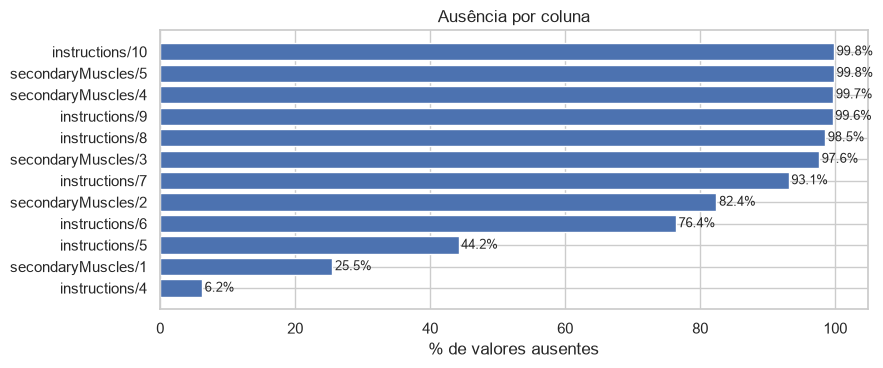

In [9]:
# Gráfico dos nulos por coluna
com_nulos = qualidade[qualidade["pct_nulos"] > 0]

if len(com_nulos):
    fig, ax = plt.subplots(figsize=(9, max(2.5, 0.32 * len(com_nulos))))
    ax.barh(com_nulos.index[::-1], com_nulos["pct_nulos"][::-1])
    ax.set_xlabel("% de valores ausentes")
    ax.set_title("Ausência por coluna")
    for i, v in enumerate(com_nulos["pct_nulos"][::-1]):
        ax.text(v + 0.4, i, f"{v}%", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma coluna com valores ausentes.")

## 2.1) O mapa da ausência

Cada linha do gráfico é uma linha da base; cada coluna, uma coluna. As marcas escuras são valores ausentes.

**O que procurar:** faixas horizontais contínuas. Ausência em bloco nunca é acaso — é troca de sistema, mudança de formulário ou falha de carga em um período.

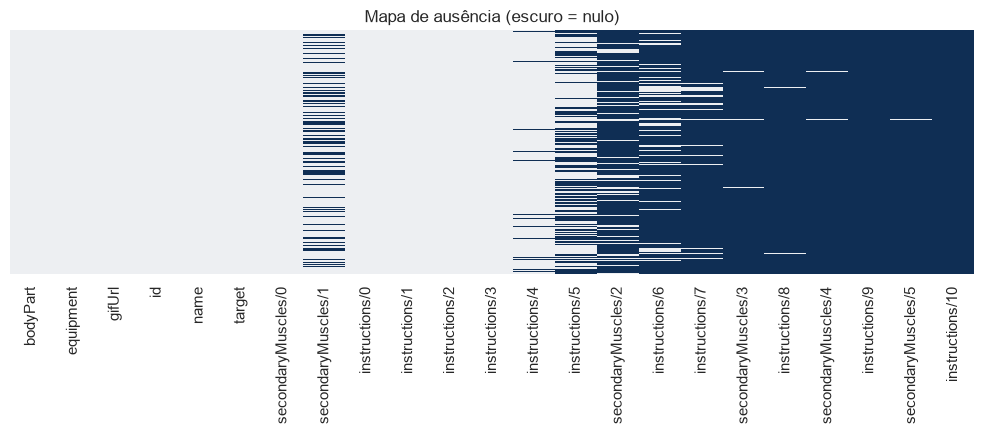

In [10]:
if df.isna().any().any():
    amostra = df if len(df) <= 500 else df.sample(500, random_state=42).sort_index()
    fig, ax = plt.subplots(figsize=(10, 4.5))
    sns.heatmap(amostra.isna(), cbar=False, yticklabels=False,
                cmap=["#EDEFF2", "#0F2E54"], ax=ax)
    ax.set_title("Mapa de ausência (escuro = nulo)")
    plt.tight_layout()
    plt.show()
else:
    print("Base sem valores ausentes — nada a mapear.")

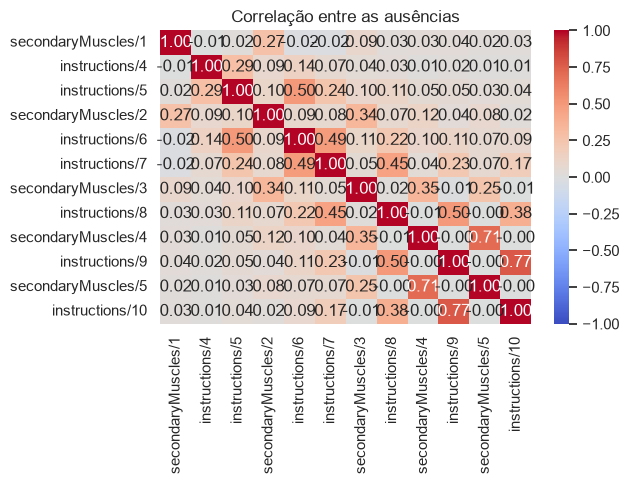

Valores próximos de 1 indicam colunas que faltam sempre juntas —
sinal de que vêm da mesma origem, que falhou.


In [11]:
# Colunas que costumam faltar juntas
nulos_bin = df.isna()
nulos_bin = nulos_bin.loc[:, nulos_bin.any()]

if nulos_bin.shape[1] >= 2:
    co = nulos_bin.corr()
    fig, ax = plt.subplots(figsize=(6.5, 5))
    sns.heatmap(co, annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, ax=ax)
    ax.set_title("Correlação entre as ausências")
    plt.tight_layout()
    plt.show()
    print("Valores próximos de 1 indicam colunas que faltam sempre juntas —")
    print("sinal de que vêm da mesma origem, que falhou.")
else:
    print("Menos de duas colunas com ausência — correlação não se aplica.")

## 2.2) Nulos disfarçados

O `isna()` só enxerga o que foi reconhecido como ausente na leitura. O resto está disfarçado de valor.

In [12]:
SUSPEITOS_TEXTO = {"", " ", "-", "--", "n/a", "na", "nao informado",
                   "não informado", "sem dado", "null", "none", "nan",
                   "?", "xx", "zzz", "000", "999", "9999", "sem informacao"}

achados = []
for col in COLS_CAT:
    s = df[col].astype(str).str.strip().str.lower()
    n = s.isin(SUSPEITOS_TEXTO).sum()
    if n:
        exemplos = s[s.isin(SUSPEITOS_TEXTO)].value_counts().head(3).to_dict()
        achados.append([col, n, round(n / len(df) * 100, 1), str(exemplos)])

if achados:
    print("NULOS DISFARÇADOS EM COLUNAS DE TEXTO")
    display(pd.DataFrame(achados, columns=["coluna", "qtd", "pct", "exemplos"]))
else:
    print("Nenhum valor de texto suspeito encontrado.")

Nenhum valor de texto suspeito encontrado.


In [13]:
# Sentinelas numéricas: valores repetidos em excesso nos extremos
SENTINELAS = [-1, 0, 99, 999, 9999, 99999, 999999, 99999999]

achados_num = []
for col in COLS_NUM:
    s = df[col].dropna()
    if s.empty:
        continue
    for v in SENTINELAS:
        n = (s == v).sum()
        if n and n / len(s) > 0.01:
            achados_num.append([col, v, n, round(n / len(s) * 100, 1)])

if achados_num:
    print("CANDIDATOS A SENTINELA NUMÉRICA (mais de 1% dos valores)")
    display(pd.DataFrame(achados_num, columns=["coluna", "valor", "qtd", "pct"]))
    print()
    print("Avalie caso a caso: zero pode ser um valor legítimo ou uma ausência disfarçada.")
else:
    print("Nenhuma sentinela numérica evidente.")

print()
print("Mínimos e máximos — o extremo costuma denunciar:")
if COLS_NUM:
    display(df[COLS_NUM].describe().T[["min", "max"]])

Nenhuma sentinela numérica evidente.

Mínimos e máximos — o extremo costuma denunciar:


In [14]:
# Duplicatas
print(f"Linhas totalmente duplicadas: {df.duplicated().sum()}")
if GRAO:
    print(f"Duplicadas no grão {GRAO}: {df.duplicated(subset=GRAO).sum()}")

if df.duplicated().sum():
    display(df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(10))

Linhas totalmente duplicadas: 0
Duplicadas no grão ['id']: 0


---
# 3) Univariada numérica

Centro, dispersão, forma e extremos — para cada variável numérica, de uma vez.

In [15]:
def descritiva_completa(df, cols):
    linhas = []
    for c in cols:
        s = df[c].dropna()
        if s.empty:
            continue
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        media, dp = s.mean(), s.std()
        linhas.append({
            "variavel": c,
            "n": len(s),
            "nulos_pct": round(df[c].isna().mean() * 100, 1),
            "media": round(media, 2),
            "mediana": round(s.median(), 2),
            "desvio": round(dp, 2),
            "cv_pct": round(dp / media * 100, 1) if media else np.nan,
            "min": round(s.min(), 2),
            "q1": round(q1, 2),
            "q3": round(q3, 2),
            "max": round(s.max(), 2),
            "iqr": round(q3 - q1, 2),
            "assimetria": round(s.skew(), 2),
            "curtose": round(s.kurtosis(), 2),
        })
    return pd.DataFrame(linhas).set_index("variavel")


if COLS_NUM:
    desc = descritiva_completa(df, COLS_NUM)
    display(desc)
else:
    print("Nenhuma coluna numérica identificada.")

Nenhuma coluna numérica identificada.


## 3.1) Leitura automática da forma

A regra aplicada abaixo é a da Aula 6: assimetria acima de 1 em módulo já pede mediana em vez de média.

In [16]:
if COLS_NUM:
    for c in desc.index:
        a = desc.loc[c, "assimetria"]
        k = desc.loc[c, "curtose"]
        cv = desc.loc[c, "cv_pct"]

        if abs(a) < 0.5:
            forma = "aproximadamente simétrica — a média representa bem"
        elif abs(a) < 1:
            forma = "levemente assimétrica — média e mediana ainda próximas"
        else:
            lado = "à direita" if a > 0 else "à esquerda"
            forma = f"FORTEMENTE assimétrica {lado} — use a mediana"

        cauda = " Caudas pesadas: extremos mais frequentes que o esperado." if k > 3 else ""
        disp = " Dispersão muito alta." if pd.notna(cv) and cv > 100 else ""

        print(f"{c}")
        print(f"   assimetria {a:+.2f} | curtose {k:+.2f} -> {forma}.{cauda}{disp}")
        print()

In [17]:
# Histograma + boxplot para cada variável numérica
for c in COLS_NUM:
    s = df[c].dropna()
    if s.empty or s.nunique() < 2:
        continue

    fig, (ax1, ax2) = plt.subplots(
        2, 1, sharex=True, figsize=(8.5, 4.2),
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})

    sns.histplot(s, bins=min(30, max(10, s.nunique())), kde=True, ax=ax1,
                 color="#0F2E54")
    ax1.axvline(s.mean(), color="#C00000", ls="--", lw=1.4, label=f"média {s.mean():.2f}")
    ax1.axvline(s.median(), color="#FFC000", ls="-", lw=1.8, label=f"mediana {s.median():.2f}")
    ax1.legend(fontsize=8)
    ax1.set_ylabel("Frequência")
    ax1.set_title(f"{c}   (n={len(s)}, nulos={df[c].isna().sum()})")

    sns.boxplot(x=s, ax=ax2, color="#8FA9C4", fliersize=3)
    ax2.set_xlabel(c)
    plt.tight_layout()
    plt.show()

→ **Onde média e mediana se afastam muito**, a distribuição é assimétrica e a média está sendo puxada por extremos. Reporte a mediana.

→ **Se o histograma tem dois picos**, o boxplot vai escondê-los. Sempre olhe os dois.

---
# 4) Univariada categórica

In [18]:
if COLS_CAT:
    card = pd.DataFrame({
        "distintos": df[COLS_CAT].nunique(dropna=True),
        "nulos_pct": (df[COLS_CAT].isna().mean() * 100).round(1),
        "mais_frequente": [df[c].mode().iloc[0] if not df[c].mode().empty else None
                           for c in COLS_CAT],
        "freq_do_top_pct": [round(df[c].value_counts(normalize=True).iloc[0] * 100, 1)
                            if df[c].notna().any() else np.nan for c in COLS_CAT],
    }).sort_values("distintos", ascending=False)

    card["leitura"] = np.select(
        [card["distintos"] <= 10, card["distintos"] <= 30, card["distintos"] <= 100],
        ["barras simples", "barras horizontais ordenadas", "top N + Outros"],
        default="cardinalidade muito alta: identificador ou texto livre?")
    display(card)
else:
    print("Nenhuma coluna categórica identificada.")

,distintos,nulos_pct,mais_frequente,freq_do_top_pct,leitura
name,1318,0.0,barbell seated calf raise,0.2,cardinalidade muito alta: identificador ou tex...
instructions/2,1078,0.0,"Engaging your abs, slowly lift your upper body...",0.9,cardinalidade muito alta: identificador ou tex...
instructions/1,985,0.0,Place your hands behind your head with your el...,1.5,cardinalidade muito alta: identificador ou tex...
instructions/3,898,0.0,Repeat for the desired number of repetitions.,4.2,cardinalidade muito alta: identificador ou tex...
instructions/0,805,0.0,Lie flat on your back with your knees bent and...,2.2,cardinalidade muito alta: identificador ou tex...
instructions/4,604,6.2,Repeat for the desired number of repetitions.,27.7,cardinalidade muito alta: identificador ou tex...
instructions/5,294,44.2,Repeat for the desired number of repetitions.,38.3,cardinalidade muito alta: identificador ou tex...
instructions/6,106,76.4,Repeat for the desired number of repetitions.,49.2,cardinalidade muito alta: identificador ou tex...
secondaryMuscles/1,35,25.5,shoulders,19.6,top N + Outros
instructions/7,32,93.1,Repeat for the desired number of repetitions.,54.3,top N + Outros


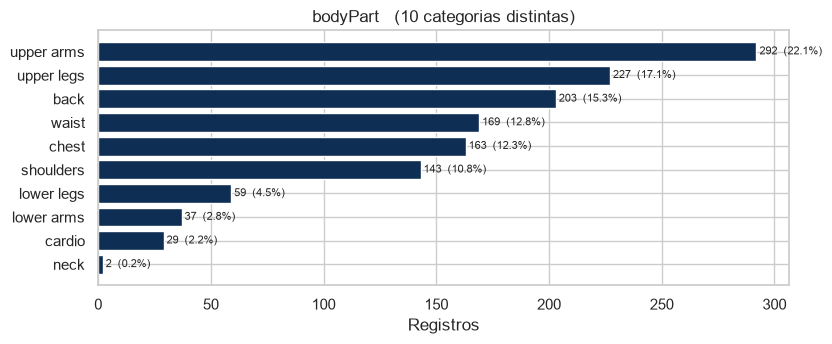

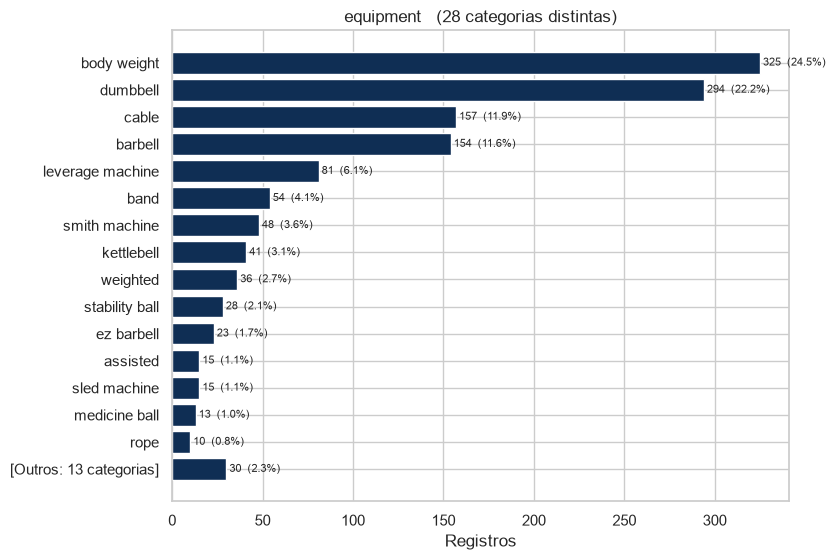

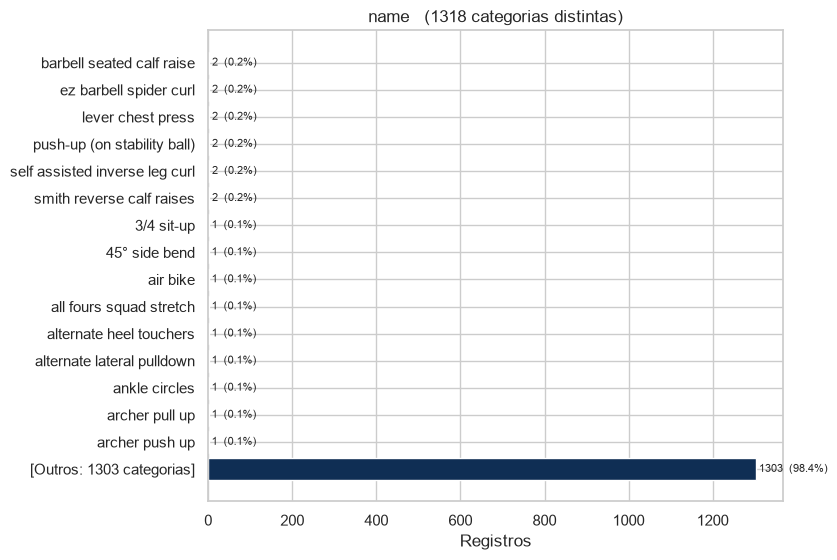

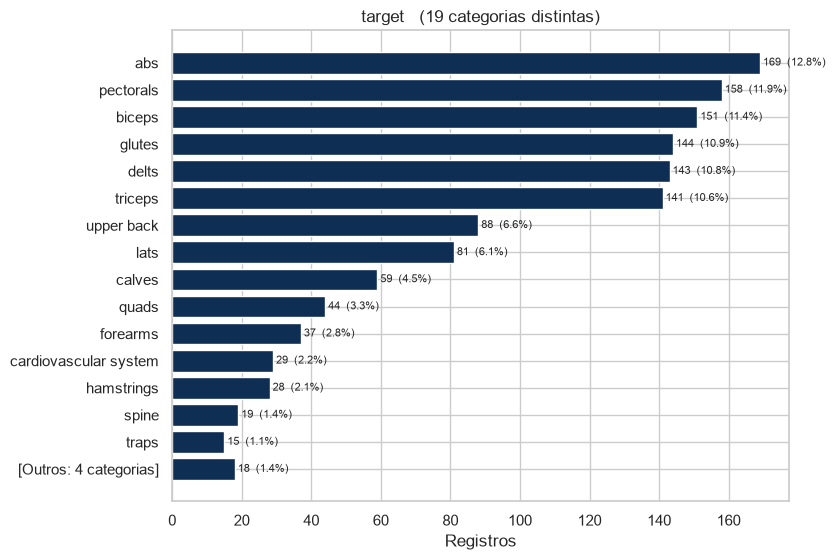

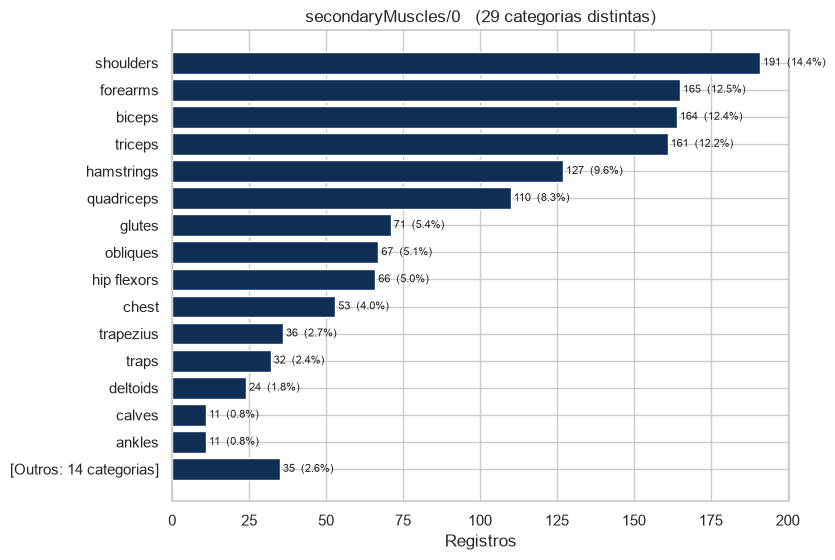

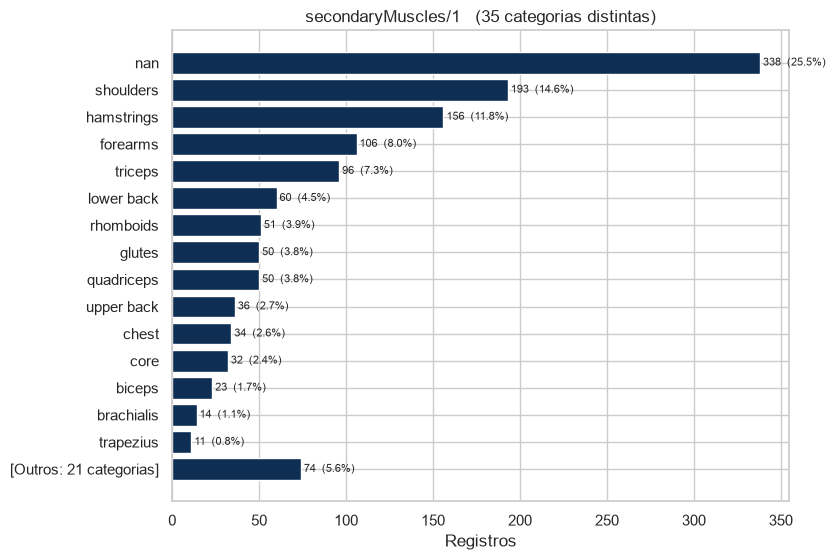

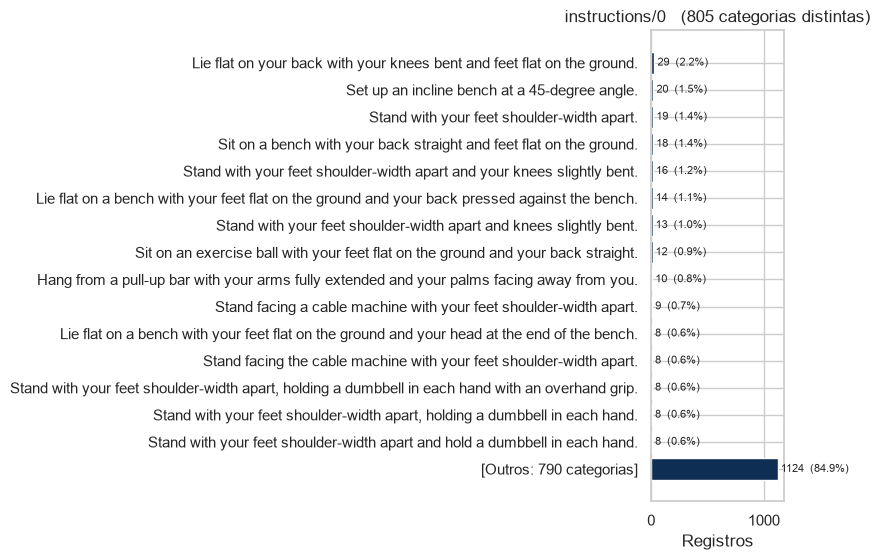

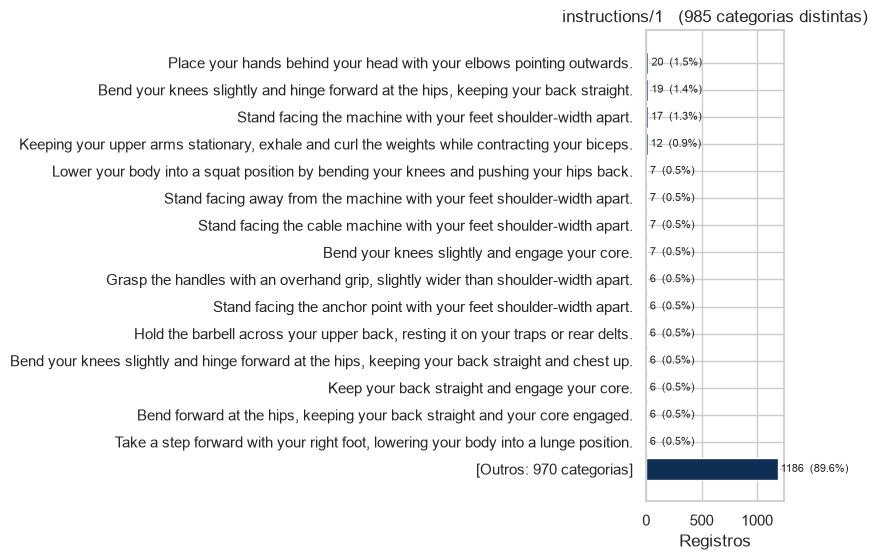

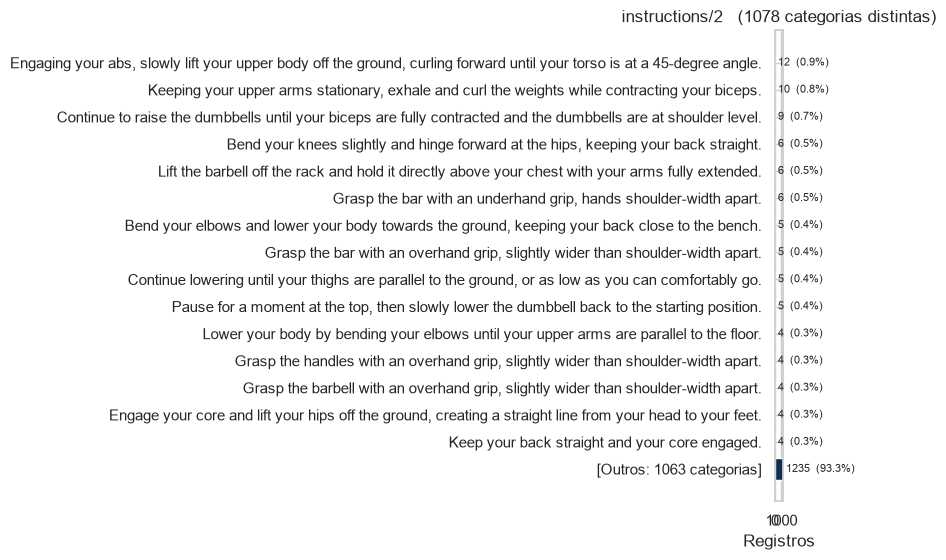

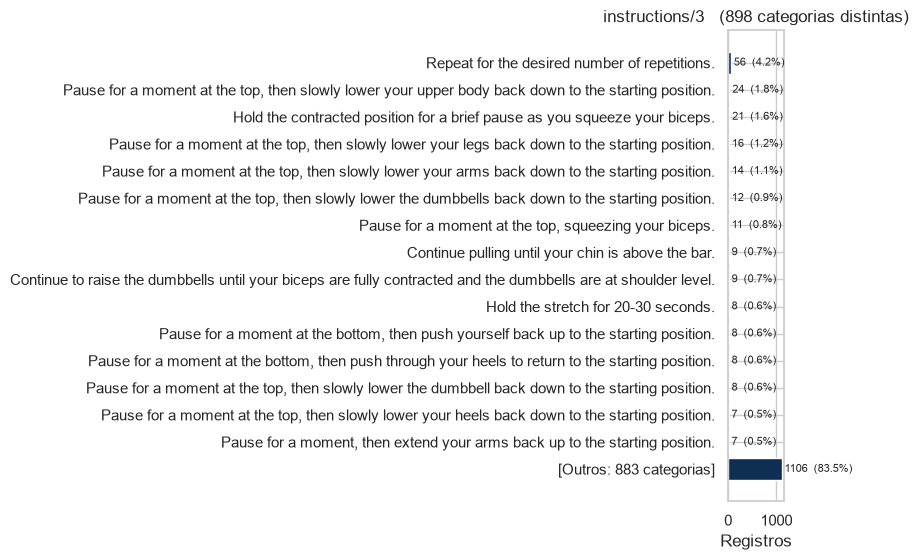

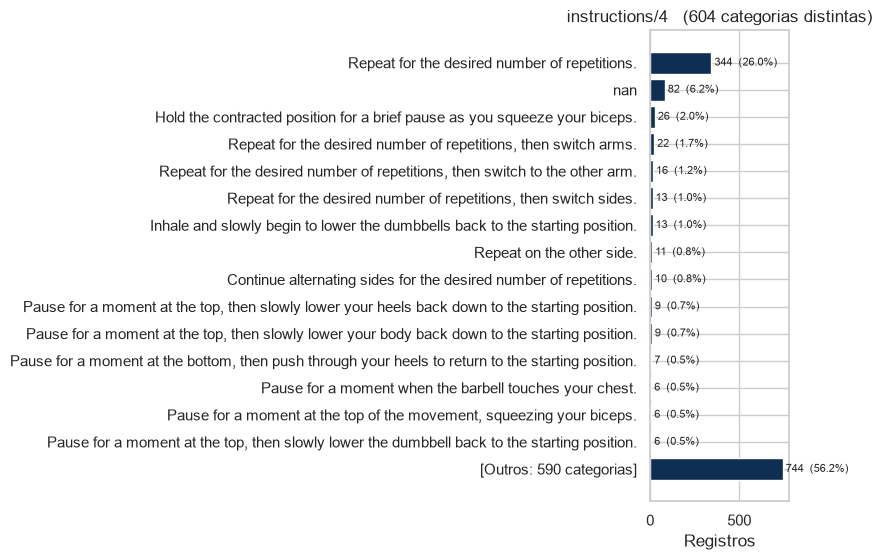

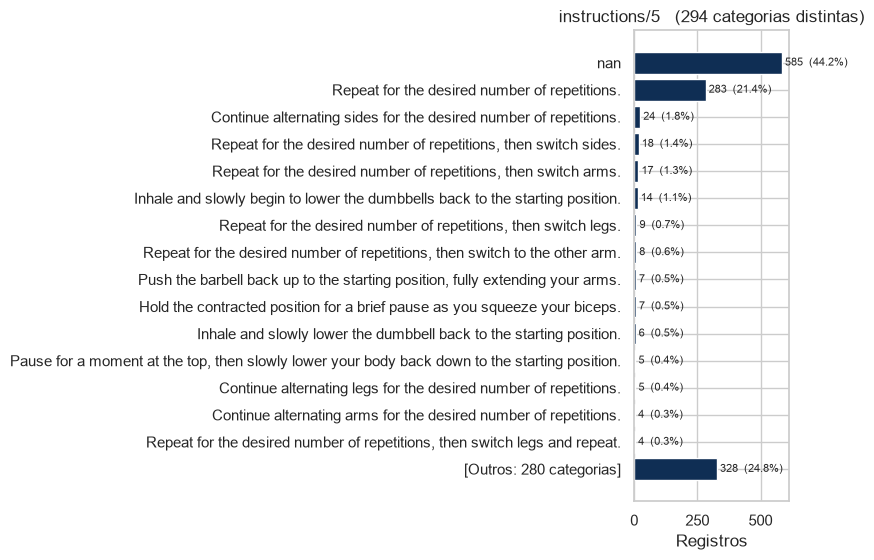

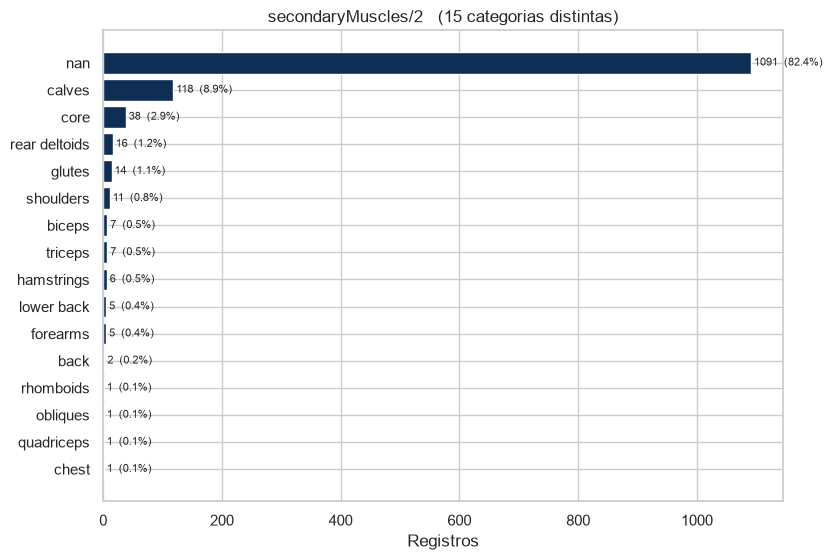

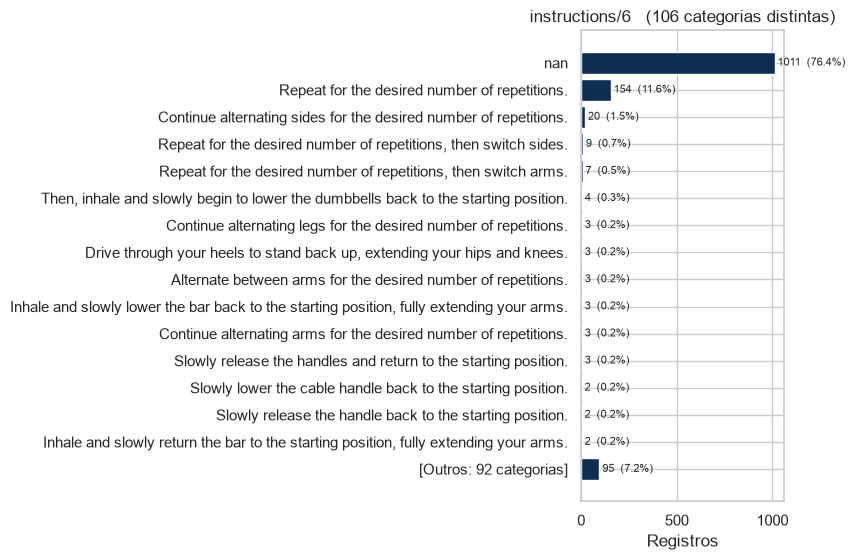

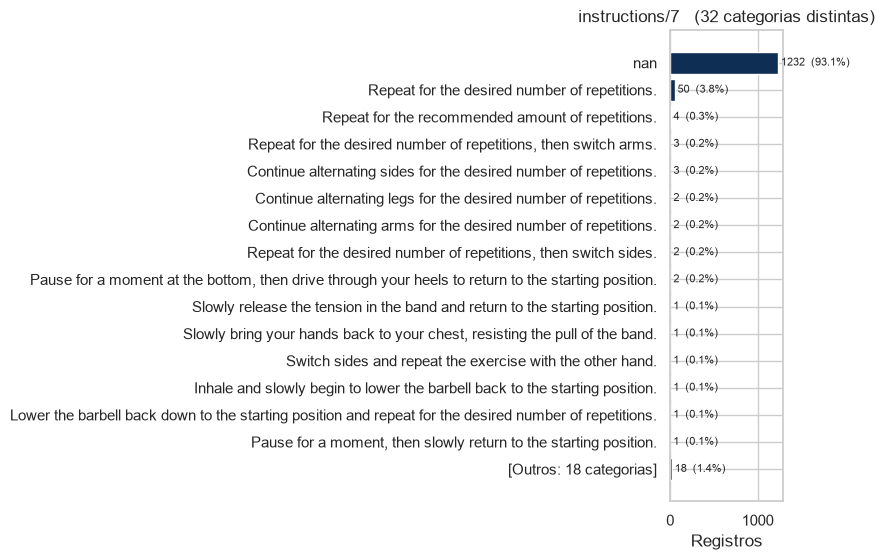

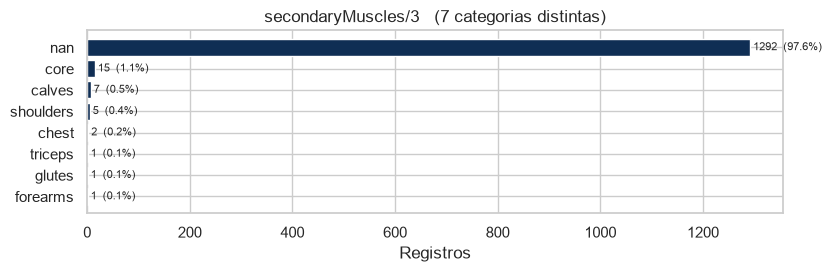

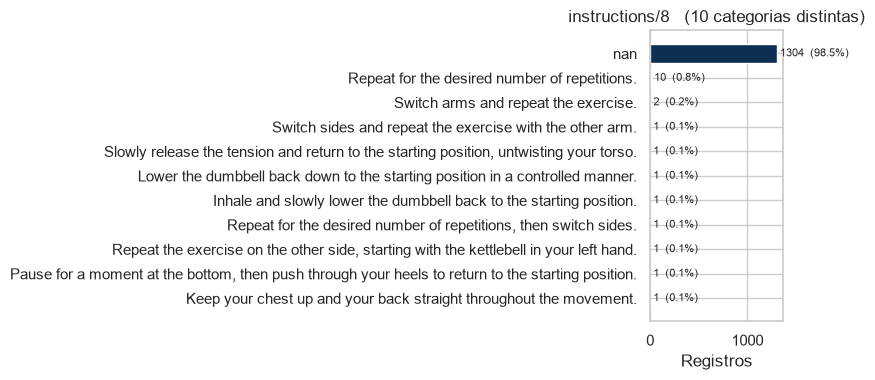

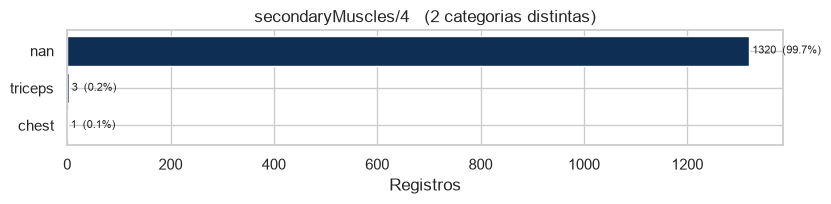

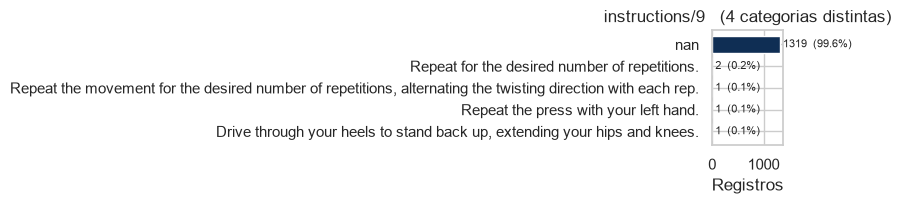

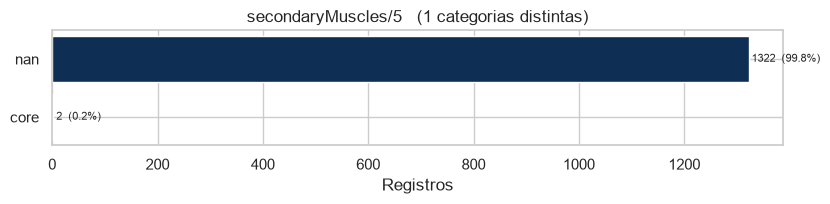

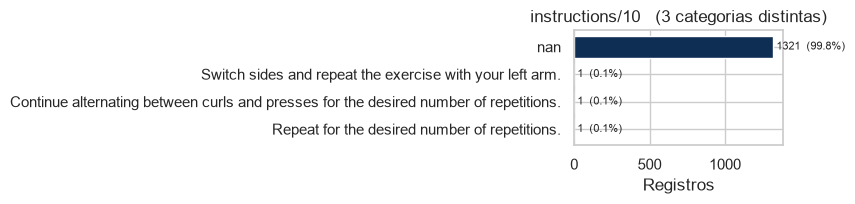

In [19]:
for c in COLS_CAT:
    vc = df[c].value_counts(dropna=False)
    if vc.empty:
        continue

    total_cat = df[c].nunique(dropna=True)
    if total_cat > MAX_CATEGORIAS:
        principais = vc.head(MAX_CATEGORIAS)
        outros = vc.iloc[MAX_CATEGORIAS:].sum()
        n_outros = len(vc) - MAX_CATEGORIAS
        principais = pd.concat([principais,
                                pd.Series({f"[Outros: {n_outros} categorias]": outros})])
    else:
        principais = vc

    fig, ax = plt.subplots(figsize=(8.5, max(2.2, 0.36 * len(principais))))
    ax.barh([str(i) for i in principais.index][::-1], principais.values[::-1],
            color="#0F2E54")
    ax.set_title(f"{c}   ({total_cat} categorias distintas)")
    ax.set_xlabel("Registros")
    for i, v in enumerate(principais.values[::-1]):
        ax.text(v, i, f" {v}  ({v/len(df)*100:.1f}%)", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

→ Categorias que aparecem escritas de formas diferentes (`SP`, `sp`, `São Paulo`) são o mesmo valor para o negócio e valores distintos para o Python. Se você vir isso aqui, volte à canonicalização da Aula 4 antes de prosseguir.

---
# 5) Outliers

Os três métodos vistos na Aula 6, aplicados lado a lado. Onde eles discordam, a decisão é sua — e precisa ser justificada.

In [20]:
def detecta_outliers(s):
    s = s.dropna()
    if len(s) < 4 or s.nunique() < 3:
        return None

    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_iqr = ((s < lim_inf) | (s > lim_sup)).sum()

    dp = s.std()
    n_z = (abs(s - s.mean()) > 3 * dp).sum() if dp else 0

    mad = (s - s.median()).abs().median()
    n_zmod = (0.6745 * (s - s.median()).abs() / mad > 3.5).sum() if mad else 0

    return {
        "n": len(s),
        "lim_inf_iqr": round(lim_inf, 2),
        "lim_sup_iqr": round(lim_sup, 2),
        "outliers_iqr": n_iqr,
        "pct_iqr": round(n_iqr / len(s) * 100, 1),
        "outliers_z3": n_z,
        "outliers_zmod": n_zmod,
    }


linhas = []
for c in COLS_NUM:
    r = detecta_outliers(df[c])
    if r:
        linhas.append({"variavel": c, **r})

if linhas:
    display(pd.DataFrame(linhas).set_index("variavel"))
    print("Onde os três métodos discordam muito, a distribuição não é normal —")
    print("e o IQR costuma ser a leitura mais confiável.")
else:
    print("Nenhuma variável numérica com dados suficientes para detecção.")

Nenhuma variável numérica com dados suficientes para detecção.


In [21]:
# As linhas extremas de cada variável, para inspeção manual
for c in COLS_NUM:
    s = df[c].dropna()
    if len(s) < 4:
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    fora = df[(df[c] < q1 - 1.5 * iqr) | (df[c] > q3 + 1.5 * iqr)]
    if len(fora):
        print(f"\n{'='*55}\n{c}: {len(fora)} candidatos a outlier\n{'='*55}")
        display(fora.nlargest(min(5, len(fora)), c).head())

→ Para cada candidato, responda a pergunta da Aula 6: **erro, evento raro ou subpopulação?**

- Erro → corrigir ou remover, documentando.
- Evento raro → manter, e reportar a métrica com e sem ele.
- Subpopulação → **segmentar**, não remover.

---
# 6) Séries temporais

Executa apenas se houver alguma coluna de data na base.

In [22]:
if COLS_DT:
    COL_TEMPO = COLS_DT[0]
    print(f"Coluna de tempo usada: {COL_TEMPO}")
    print(f"Período: {df[COL_TEMPO].min()}  ->  {df[COL_TEMPO].max()}")
    print(f"Registros sem data: {df[COL_TEMPO].isna().sum()}")

    tmp = df.dropna(subset=[COL_TEMPO]).set_index(COL_TEMPO).sort_index()
    dias = (tmp.index.max() - tmp.index.min()).days
    freq = "D" if dias <= 90 else ("W" if dias <= 730 else "MS")
    rotulo = {"D": "dia", "W": "semana", "MS": "mês"}[freq]
    print(f"Amplitude: {dias} dias -> agregando por {rotulo}")
else:
    print("Nenhuma coluna de data identificada. Seção 6 ignorada.")
    print("Se a sua base tem datas, informe-as em COLS_DATA na configuração.")

Nenhuma coluna de data identificada. Seção 6 ignorada.
Se a sua base tem datas, informe-as em COLS_DATA na configuração.


In [23]:
if COLS_DT:
    volume = tmp.resample(freq).size()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(volume.index, volume.values, lw=1.6, color="#0F2E54", label="registros")
    if len(volume) >= 5:
        jan = max(3, min(7, len(volume) // 3))
        ax.plot(volume.index, volume.rolling(jan, min_periods=2).mean(),
                lw=2.2, color="#FFC000", label=f"média móvel ({jan})")
    ax.set_title(f"Volume de registros por {rotulo}")
    ax.set_ylabel("Registros")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("Procure: degraus (troca de sistema), buracos (falha de carga)")
    print("e o último período, que costuma estar incompleto.")

In [24]:
if COLS_DT:
    dias_pt = {"Monday": "2ª", "Tuesday": "3ª", "Wednesday": "4ª", "Thursday": "5ª",
               "Friday": "6ª", "Saturday": "Sáb", "Sunday": "Dom"}
    ordem = ["2ª", "3ª", "4ª", "5ª", "6ª", "Sáb", "Dom"]

    d = df.dropna(subset=[COL_TEMPO]).copy()
    d["_dia"] = d[COL_TEMPO].dt.day_name().map(dias_pt)
    d["_hora"] = d[COL_TEMPO].dt.hour

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    por_dia = d["_dia"].value_counts().reindex(ordem).fillna(0)
    axes[0].bar(por_dia.index, por_dia.values, color="#0F2E54")
    axes[0].set_title("Sazonalidade — dia da semana")

    if d["_hora"].nunique() > 1:
        por_hora = d["_hora"].value_counts().sort_index()
        axes[1].bar(por_hora.index, por_hora.values, color="#0F2E54")
        axes[1].set_title("Sazonalidade — hora do dia")
        axes[1].set_xlabel("Hora")
    else:
        axes[1].text(0.5, 0.5, "Sem informação de hora",
                     ha="center", va="center", transform=axes[1].transAxes)
        axes[1].axis("off")
    plt.tight_layout()
    plt.show()

---
# 7) Bivariada

A matriz de decisão da Aula 6 aplicada automaticamente: para cada par relevante, o gráfico correspondente ao par de tipos.

In [25]:
# Numérica x Numérica — dispersão dos pares mais correlacionados
if len(COLS_NUM) >= 2:
    corr_s = df[COLS_NUM].corr(method="spearman").abs()
    pares = (corr_s.where(np.triu(np.ones(corr_s.shape), k=1).astype(bool))
                   .stack().sort_values(ascending=False))
    top = pares.head(3)

    print("Pares numéricos com maior associação (Spearman, em módulo):")
    display(top.round(3).to_frame("spearman_abs"))

    for (a, b), _ in top.items():
        fig, ax = plt.subplots(figsize=(6, 4))
        sns.scatterplot(data=df, x=a, y=b, alpha=0.35, s=28,
                        color="#0F2E54", ax=ax)
        p = df[[a, b]].corr().iloc[0, 1]
        sp = df[[a, b]].corr(method="spearman").iloc[0, 1]
        ax.set_title(f"{a} x {b}   Pearson {p:.2f} | Spearman {sp:.2f}")
        plt.tight_layout()
        plt.show()
else:
    print("Menos de duas variáveis numéricas — dispersão não se aplica.")

Menos de duas variáveis numéricas — dispersão não se aplica.


In [26]:
# Categórica x Numérica — boxplot por categoria
pares_feitos = 0
for cat in COLS_CAT:
    if not (2 <= df[cat].nunique() <= 12):
        continue
    for num in COLS_NUM[:3]:
        fig, ax = plt.subplots(figsize=(8.5, 4))
        ordem_cat = df.groupby(cat)[num].median().sort_values().index
        sns.boxplot(data=df, x=cat, y=num, order=ordem_cat,
                    color="#8FA9C4", ax=ax)
        ns = df.groupby(cat)[num].count().reindex(ordem_cat)
        ax.set_xticklabels([f"{c}\n(n={ns[c]})" for c in ordem_cat], fontsize=8)
        ax.set_title(f"{num} por {cat}")
        plt.tight_layout()
        plt.show()
        pares_feitos += 1
        if pares_feitos >= 6:
            break
    if pares_feitos >= 6:
        break

if pares_feitos == 0:
    print("Nenhum par categórica x numérica adequado encontrado.")

Nenhum par categórica x numérica adequado encontrado.


Contagem — bodyPart x secondaryMuscles/3


secondaryMuscles/3,calves,chest,core,forearms,glutes,shoulders,triceps
bodyPart,,,,,,,
back,0,2,1,1,0,0,0
cardio,7,0,0,0,1,3,0
shoulders,0,0,1,0,0,0,0
upper legs,0,0,13,0,0,0,1
waist,0,0,0,0,0,2,0



Proporção por linha (o que se deve ler)


secondaryMuscles/3,calves,chest,core,forearms,glutes,shoulders,triceps
bodyPart,,,,,,,
back,0.0,50.0,25.0,25.0,0.0,0.0,0.0
cardio,63.6,0.0,0.0,0.0,9.1,27.3,0.0
shoulders,0.0,0.0,100.0,0.0,0.0,0.0,0.0
upper legs,0.0,0.0,92.9,0.0,0.0,0.0,7.1
waist,0.0,0.0,0.0,0.0,0.0,100.0,0.0


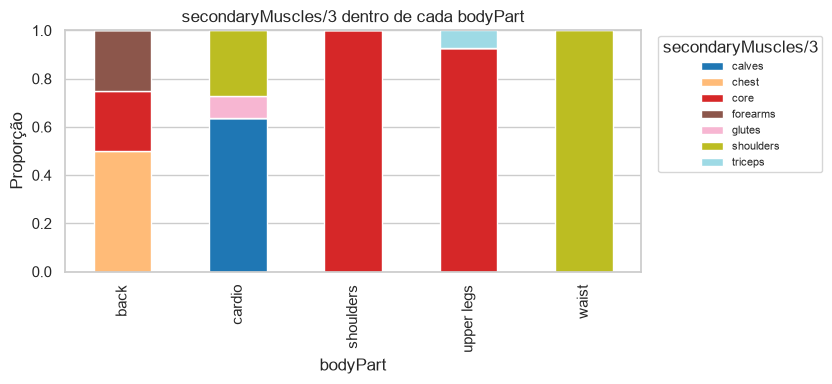

In [27]:
# Categórica x Categórica — proporção por linha, nunca contagem
cats_ok = [c for c in COLS_CAT if 2 <= df[c].nunique() <= 10]

if len(cats_ok) >= 2:
    a, b = cats_ok[0], cats_ok[1]
    ct_n = pd.crosstab(df[a], df[b])
    ct_p = pd.crosstab(df[a], df[b], normalize="index")

    print(f"Contagem — {a} x {b}")
    display(ct_n)
    print(f"\nProporção por linha (o que se deve ler)")
    display((ct_p * 100).round(1))

    fig, ax = plt.subplots(figsize=(8.5, 4))
    ct_p.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
    ax.set_ylabel("Proporção")
    ax.set_title(f"{b} dentro de cada {a}")
    ax.legend(title=b, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Menos de duas categóricas adequadas para tabela de contingência.")

---
# 8) Correlação

Pearson mede relação **linear**. Spearman mede relação **monotônica**, sobre os postos. Quando os dois discordam, existe relação — só não é uma reta.

In [28]:
if len(COLS_NUM) >= 2:
    p = df[COLS_NUM].corr(method="pearson")
    s = df[COLS_NUM].corr(method="spearman")
    mask = np.triu(np.ones_like(p, dtype=bool))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
    sns.heatmap(p, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, ax=axes[0], cbar=False)
    axes[0].set_title("Pearson (linear)")
    sns.heatmap(s, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, ax=axes[1], cbar=False)
    axes[1].set_title("Spearman (postos)")
    plt.tight_layout()
    plt.show()

    dif = (s - p).abs()
    dif = dif.where(np.triu(np.ones(dif.shape), k=1).astype(bool)).stack()
    fortes = dif[dif > 0.15].sort_values(ascending=False)
    if len(fortes):
        print("Pares em que Pearson e Spearman discordam (diferença > 0,15):")
        display(fortes.round(3).to_frame("diferenca"))
        print("Relação provavelmente não linear, ou influenciada por outliers.")
        print("Olhe o gráfico de dispersão antes de concluir qualquer coisa.")
    else:
        print("Pearson e Spearman concordam em todos os pares.")
else:
    print("Menos de duas variáveis numéricas.")

Menos de duas variáveis numéricas.


> **Lembrete de Anscombe:** nenhum número desta matriz entra no relatório sem o gráfico de dispersão correspondente ao lado.

---
# 9) Segmentação

A métrica principal por cada dimensão categórica — **sempre com o n ao lado**, como visto na Aula 6.

In [29]:
ALVO = COL_ALVO if COL_ALVO in df.columns else (COLS_NUM[0] if COLS_NUM else None)

if ALVO is None:
    print("Nenhuma variável-alvo disponível. Defina COL_ALVO na configuração.")
elif ALVO in COLS_NUM:
    print(f"Variável analisada: {ALVO} (numérica)\n")
    for cat in COLS_CAT:
        if not (2 <= df[cat].nunique() <= 20):
            continue
        seg = (df.groupby(cat)[ALVO]
                 .agg(n="size", media="mean", mediana="median", desvio="std")
                 .round(2)
                 .sort_values("media", ascending=False))
        seg["confiavel"] = np.where(seg["n"] >= MIN_N_SEGMENTO, "sim", "N BAIXO")
        print(f"--- {ALVO} por {cat} ---")
        display(seg)
else:
    print(f"Variável analisada: {ALVO} (categórica)\n")
    for cat in COLS_CAT:
        if cat == ALVO or not (2 <= df[cat].nunique() <= 20):
            continue
        ct = pd.crosstab(df[cat], df[ALVO], normalize="index").round(3) * 100
        ct["n"] = df[cat].value_counts()
        ct["confiavel"] = np.where(ct["n"] >= MIN_N_SEGMENTO, "sim", "N BAIXO")
        print(f"--- {ALVO} por {cat} (% por linha) ---")
        display(ct)

Nenhuma variável-alvo disponível. Defina COL_ALVO na configuração.


→ Segmentos marcados como **N BAIXO** têm poucos registros: a métrica deles oscila muito por construção e não sustenta recomendação. Trate-os separadamente, ou agrupe.

---
# 10) Multivariada

Facetas e o teste de Simpson.

In [30]:
# Facetas: a mesma relação, repetida dentro de cada valor de uma terceira variável
cats_faceta = [c for c in COLS_CAT if 2 <= df[c].nunique() <= 4]

if cats_faceta and len(COLS_NUM) >= 2:
    faceta = cats_faceta[0]
    x, y = COLS_NUM[0], COLS_NUM[1]
    g = sns.relplot(data=df, x=x, y=y, col=faceta, kind="scatter",
                    alpha=0.4, height=3.2, aspect=1.1,
                    facet_kws={"sharex": True, "sharey": True})
    g.figure.suptitle(f"{x} x {y}, por {faceta}", y=1.04)
    plt.show()
    print("Eixos fixos em todos os painéis — é o que torna os painéis comparáveis.")
else:
    print("Sem combinação adequada para facetas.")

Sem combinação adequada para facetas.


In [31]:
def teste_simpson(df, grupo, segmento, metrica):
    """Compara a direção da métrica no agregado e dentro de cada segmento."""
    agregado = df.groupby(grupo)[metrica].mean()
    vencedor_geral = agregado.idxmax()

    por_seg = df.groupby([segmento, grupo])[metrica].mean().unstack()
    por_seg = por_seg.dropna()
    if por_seg.empty:
        return None

    vencedores = por_seg.idxmax(axis=1)
    invertidos = vencedores[vencedores != vencedor_geral]

    margem = round(float(agregado.max() - agregado.min()), 4)

    return {
        "margem_agregado": margem,
        "agregado": agregado.round(3),
        "por_segmento": por_seg.round(3),
        "composicao": pd.crosstab(df[grupo], df[segmento], normalize="index").round(3),
        "vencedor_geral": vencedor_geral,
        "segmentos_invertidos": list(invertidos.index),
    }


grupos_ok = [c for c in COLS_CAT if 2 <= df[c].nunique() <= 5]

# Se o alvo for categórico binário, vira uma métrica 0/1 — bem mais informativo
df_s = df.copy()
metrica = None
if COL_ALVO in df.columns and df[COL_ALVO].nunique(dropna=True) == 2:
    niveis = sorted(df[COL_ALVO].dropna().unique())
    df_s["_taxa_alvo"] = (df_s[COL_ALVO] == niveis[-1]).astype(float)
    metrica = "_taxa_alvo"
    print(f"Métrica: proporção de '{niveis[-1]}' em {COL_ALVO}")
elif COLS_NUM:
    metrica = COLS_NUM[0]
    print(f"Métrica: {metrica}")

grupos_ok = [c for c in grupos_ok if c != COL_ALVO]

if len(grupos_ok) >= 2 and metrica:
    grupo, segmento = grupos_ok[0], grupos_ok[1]
    df = df_s
    print(f"Grupos: {grupo}   |   Segmentado por: {segmento}\n")

    r = teste_simpson(df, grupo, segmento, metrica)
    if r:
        print("No agregado:")
        display(r["agregado"])
        print("\nPor segmento:")
        display(r["por_segmento"])
        print("\nComposição de cada grupo (é aqui que o paradoxo nasce):")
        display(r["composicao"])

        if r["segmentos_invertidos"]:
            print("\n" + "!" * 60)
            print(f"ATENÇÃO: no agregado vence '{r['vencedor_geral']}',")
            print(f"mas em {r['segmentos_invertidos']} o vencedor é outro.")
            print(f"Margem no agregado: {r['margem_agregado']}")
            print("Verifique se a diferença é grande o bastante para importar.")
            print("Isto é o paradoxo de Simpson. NÃO reporte apenas o agregado.")
            print("!" * 60)
        else:
            print("\nDireção consistente entre agregado e segmentos — sem inversão.")
else:
    print("Combinação insuficiente para o teste de Simpson.")
    print("Ele exige duas categóricas de poucos níveis e uma métrica numérica.")

Combinação insuficiente para o teste de Simpson.
Ele exige duas categóricas de poucos níveis e uma métrica numérica.


→ O teste acima roda no primeiro par de categóricas encontrado. **Rode-o manualmente** para as combinações que fazem sentido no seu domínio — é o conhecimento do negócio que aponta onde procurar confundimento, não o código.

```python
r = teste_simpson(df, grupo="unidade", segmento="faixa_etaria", metrica="faltou")
```

---
# 11) Síntese

A EDA não termina em gráficos. Termina em **achados, hipóteses e decisões**.

Preencha a célula abaixo com as suas conclusões — é este texto, e não os gráficos, que vai para o relatório do PI.

In [32]:
SINTESE = """
ACHADOS
   Afirmações sobre o dado, cada uma com a medida e o gráfico que a sustentam.
   1. A base possui 1.324 registros e 23 colunas. Depois da retirada dos identificadores `id` e `gifUrl`, as 21 colunas analisadas são categóricas; não foram encontradas colunas numéricas ou de data. Isso é confirmado pela classificação de tipos e pelos gráficos de frequência.
   2. O campo `id` funciona como identificador do registro: possui valores únicos e não apresentou duplicidades no grão declarado. Também não foram encontrados valores de texto suspeitos na verificação de nulos disfarçados.
   3. Os valores ausentes estão concentrados nos campos opcionais. Por exemplo, `secondaryMuscles/2` possui 1.091 ausências, `instructions/5` possui 585 e `secondaryMuscles/1` possui 338. Os campos principais de identificação do exercício, como `bodyPart`, `equipment`, `name`, `target` e `instructions/0`, estão preenchidos.

HIPÓTESES
   Explicações candidatas para os achados, e o que seria preciso para verificar cada uma.
   1. As ausências dos músculos secundários e das instruções finais provavelmente acontecem porque esses campos são opcionais e variam conforme o exercício, e não necessariamente por erro de carregamento. Para verificar isso, seria necessário comparar a origem da API/arquivo e validar alguns exercícios com um profissional da área.
   2. A grande quantidade de textos e a ausência de medidas numéricas indicam que a base foi criada para consulta de exercícios e não para medir desempenho ou evolução de alunos. Essa hipótese pode ser verificada comparando a base com os dados de alunos, agendamentos e treinos realizados na aplicação.

DECISÕES DE TRATAMENTO
   O que fazer com outliers, ausentes e categorias raras encontrados, com justificativa.
   1. Não foram aplicados tratamentos de outliers, pois a base não possui variáveis numéricas. Os identificadores `id` e `gifUrl` foram mantidos como referência, mas retirados das análises de categorias e métricas.
   2. Os valores ausentes dos campos opcionais não foram preenchidos artificialmente. No tratamento, as colunas de instruções foram consolidadas em `instructions_sumarization`, ignorando os campos vazios e mantendo a ordem dos passos. Os músculos secundários foram separados em uma relação própria, sem criar músculos inexistentes.
   3. As categorias foram mantidas, inclusive as menos frequentes, porque representam exercícios, equipamentos ou músculos que podem ser úteis em consultas específicas. A organização em tabelas relacionadas reduz a repetição e facilita a busca no banco.

LIMITAÇÕES
   O que esta base não permite responder, e por quê.
   1. A base não permite avaliar desempenho, evolução, carga, duração, frequência cardíaca, número de repetições ou resultados dos alunos, pois não possui essas medidas nem histórico individual.
   2. A base não permite analisar tendências ao longo do tempo, correlações, outliers numéricos ou segmentações por métricas, pois não possui datas nem variáveis numéricas.
   3. A base descreve exercícios, mas não informa se um exercício é adequado para uma pessoa específica. As recomendações do LLM devem ser revisadas por um profissional de educação física, e os dados dos exercícios precisam ser validados antes do uso em produção.
"""

print(SINTESE)


ACHADOS
   Afirmações sobre o dado, cada uma com a medida e o gráfico que a sustentam.
   1. A base possui 1.324 registros e 23 colunas. Depois da retirada dos identificadores `id` e `gifUrl`, as 21 colunas analisadas são categóricas; não foram encontradas colunas numéricas ou de data. Isso é confirmado pela classificação de tipos e pelos gráficos de frequência.
   2. O campo `id` funciona como identificador do registro: possui valores únicos e não apresentou duplicidades no grão declarado. Também não foram encontrados valores de texto suspeitos na verificação de nulos disfarçados.
   3. Os valores ausentes estão concentrados nos campos opcionais. Por exemplo, `secondaryMuscles/2` possui 1.091 ausências, `instructions/5` possui 585 e `secondaryMuscles/1` possui 338. Os campos principais de identificação do exercício, como `bodyPart`, `equipment`, `name`, `target` e `instructions/0`, estão preenchidos.

HIPÓTESES
   Explicações candidatas para os achados, e o que seria preciso para ver

In [33]:
# Exportação da base tratada e do relatório de qualidade
df.to_csv("base_tratada.csv", index=False, encoding="utf-8-sig")
qualidade.to_csv("relatorio_qualidade.csv", encoding="utf-8-sig")

if COLS_NUM:
    desc.to_csv("estatistica_descritiva.csv", encoding="utf-8-sig")

print("Arquivos gerados:")
print("   base_tratada.csv")
print("   relatorio_qualidade.csv")
if COLS_NUM:
    print("   estatistica_descritiva.csv")

Arquivos gerados:
   base_tratada.csv
   relatorio_qualidade.csv


---

## Antes de entregar

- [ ] A configuração aponta para a base do seu PI, não para a base de exemplo
- [ ] A coluna `perda_pct` foi conferida: nenhuma conversão perdeu dados em silêncio
- [ ] Os nulos disfarçados encontrados foram acrescentados a `NA_EXTRA` e o notebook foi rodado de novo
- [ ] Cada candidato a outlier foi classificado: erro, evento raro ou subpopulação
- [ ] O teste de Simpson foi rodado nas combinações que fazem sentido no seu domínio
- [ ] A célula de síntese está preenchida

---

*SPTech School — Análise de Dados — Prof. Rodrigo Fernandes*